# Riemannian Cell Flow for predicting cytokine effects on PBMCs

## Setting up the data

I begin by copying from the `100_pbmc.ipynb` notebook to get the latent space representations of the cell states produced by PCA.

In [1]:
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", SettingWithCopyWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import jax
import functools
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import flax.linen as nn
import optax
import cellflow
from cellflow.model import CellFlow
import cellflow.preprocessing as cfpp
from cellflow.utils import match_linear
from cellflow.plotting import plot_condition_embedding
from cellflow.preprocessing import transfer_labels, compute_wknn, centered_pca, project_pca, reconstruct_pca
from cellflow.metrics import compute_r_squared, compute_e_distance

C:\Users\marku\PycharmProjects\CellFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = cellflow.datasets.pbmc_cytokines()

In [ ]:
adata.obs.head()

For the sake of testing the knn on a small subset, label every sample as "is_control"

In [2]:
adata.obs["condition"] = adata.obs.apply(lambda x: x["donor"] + "_" + x["cytokine"], axis=1)
adata.obs["is_control"] = adata.obs.apply(lambda x: True if x["cytokine"]=="PBS" else False, axis=1)

NameError: name 'adata' is not defined

In [ ]:
adata.write("pbmc.h5ad")

In [2]:
adata = ad.read_h5ad("pbmc.h5ad")

In [3]:
adata_small = adata[:10000,:]

In [4]:
sc.pp.normalize_total(adata_small, target_sum=1e4)
sc.pp.log1p(adata_small)

In [5]:
adata_train = adata_small[(adata_small.obs["cytokine"]!="IL-15") | (adata_small.obs["donor"]=="Donor8")].copy()
adata_test = adata_small[((adata_small.obs["cytokine"]=="IL-15") & (adata_small.obs["donor"]!="Donor8")) | (adata_small.obs["cytokine"]=="PBS")].copy()
adata_train.n_obs, adata_test.n_obs

(9886, 677)

In [6]:
adata_train.obs["is_control"]

89_103_005__s1    False
89_103_083__s1    False
89_103_085__s1    False
89_104_009__s1    False
89_104_025__s1    False
                  ...  
34_119_006__s1    False
34_119_017__s1    False
34_119_018__s1    False
34_119_036__s1    False
34_119_051__s1    False
Name: is_control, Length: 9886, dtype: bool

In [7]:
cfpp.centered_pca(adata_train, n_comps=20, keep_centered_data=False)
cfpp.project_pca(query_adata=adata_test, ref_adata=adata_train)

In [ ]:
adata_train.obs.head()

In [ ]:
adata_train.X

In [8]:
cf = CellFlow(adata_train, solver="otrfm")

In [9]:
cf.prepare_data(
    sample_rep = "X_pca",
    control_key = "is_control",
    perturbation_covariates = {"cytokine_treatment": ("cytokine",)},
    perturbation_covariate_reps = {"cytokine_treatment": "esm2_embeddings"},
    sample_covariates = ["donor"],
    sample_covariate_reps = {"donor": "donor_embeddings"},
    split_covariates = ["donor"],
    max_combination_length = 1,
    null_value = 0.0,
)

[########################################] | 100% Completed | 102.37 ms
[########################################] | 100% Completed | 102.88 ms
[########################################] | 100% Completed | 102.70 ms


In [10]:
pca_data = cf.train_data.cell_data

## Precompute pre-metric on latent space data manifold

Now that we have our cell data in the latent space representation produced by the PCA, let us set up the knn-graph, compute the Laplacian and its first k eigenvectors to get the approximated spectral distances between the points.

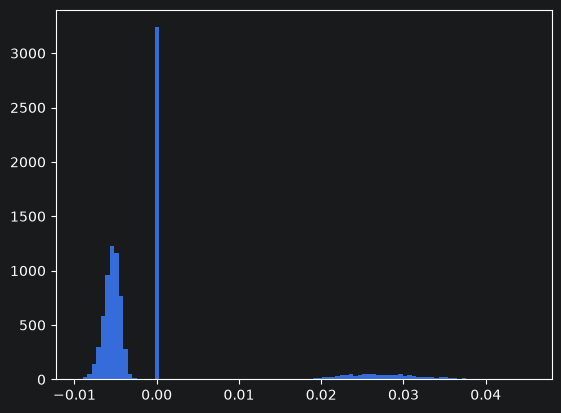

In [11]:
from cellflow.preprocessing._premetric import *

# Build the kNN graph.
W, sigma = build_knn_graph(pca_data, k=30)
# Compute the normalized Laplacian
L = normalized_laplacian(W)
# Calculate the first k eigenfunctions of the Laplacian
s_dim = 11
evals, evecs = compute_eigens(L, k=s_dim)
evals = evals[1:]
evecs = evecs[:,1:]
plt.hist(evecs[:,1], bins=100)
Psi = spectral_embedding(evals, evecs, weight_type="biharmonic")

Psi_norm = np.sum(Psi**2, axis=1)

# Precompute squared distances for two known points i and j (i.e. 0 and 1):
n = Psi.shape[0]
D = np.zeros((n, n))
D = Psi_norm[:, None] + Psi_norm[None, :] - 2 * (Psi @ Psi.T)

Having computed D, we can use the saved distances to approximate the spectral embeddings of unseen points by streaming: We interpolate between the k nearest neighbors using gaussian kernel weighting.

In [12]:
cf.prepare_validation_data(
    adata_test,
    name="test",
    n_conditions_on_log_iteration=None,
    n_conditions_on_train_end=None,
)

[########################################] | 100% Completed | 102.88 ms
[########################################] | 100% Completed | 102.65 ms
[########################################] | 100% Completed | 102.73 ms


In [13]:
unseen_pca = cf.validation_data["test"].cell_data

new_point = unseen_pca[0,:]

In [14]:
point_dict = {}

nystroem = SpectralNystroem(pca_data, evecs, evals, s_dim)
new_emb = nystroem.embed_point(new_point)

There is still some normalization to do. The distances between the points are rather big. The interpolation between the points does not work yet.

## Prepare the CellFlow model

In [15]:
layers_before_pool = {
    "cytokine_treatment": {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
    "donor": {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.0},
}

layers_after_pool = {
    "layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.0,
}

In [16]:
match_fn = functools.partial(match_linear, epsilon=0.5, tau_a=1.0, tau_b=1.0)

In [17]:
cf.prepare_model(
    condition_mode="deterministic",
    regularization=0.0,
    pooling="attention_token",
    pooling_kwargs={},
    layers_before_pool=layers_before_pool,
    layers_after_pool=layers_after_pool,
    condition_embedding_dim=256,
    cond_output_dropout=0.9,
    condition_encoder_kwargs={},
    pool_sample_covariates=True,
    time_freqs=1024,
    time_encoder_dims=[1024, 1024, 1024],
    time_encoder_dropout=0.0,
    hidden_dims=[2048, 2048, 2048],
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=[4096, 4096, 4096],
    vf_act_fn=nn.silu,
    vf_kwargs=None,
    probability_path={"constant_noise": 0.5},
    match_fn=match_fn,
    optimizer=optax.MultiSteps(optax.adam(5e-5), 20),
    solver_kwargs={},
    layer_norm_before_concatenation=False,
    linear_projection_before_concatenation=False,
    nystroem = nystroem
)

In [18]:
metrics_callback = cellflow.training.Metrics(metrics=["r_squared", "mmd", "e_distance"])
decoded_metrics_callback = cellflow.training.PCADecodedMetrics(ref_adata=adata_train, metrics=["r_squared"])
wandb_callback = cellflow.training.WandbLogger(project="cellflow_tutorials", out_dir="~", config={"name": "100m_pbmc"})

# we don't pass the wandb_callback as it requires a user-specific account, but recommend setting it up
callbacks = [metrics_callback, decoded_metrics_callback]

In [ ]:
cf.train(
        num_iterations=1,
        batch_size=512,
        callbacks=callbacks,
        valid_freq=20_000,
    )

  0%|          | 0/1 [00:00<?, ?it/s]